In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")
sns.color_palette(palette='Paired')

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [2]:
# loda the dataframe
df = pd.read_csv('/Users/jhonchristianrozano/Documents/Programming/Python Programming/Exploratory Data Analysis/Personal Expenses/expenses_2024.csv')

In [3]:
df.dtypes

Expense           object
Amount            object
Category          object
Date              object
Interest/Debt    float64
dtype: object

In [4]:
# remove peso signs and commas in amount and change it to float, same with dates
df['Amount'] = df['Amount'].str.replace('₱', '')
df['Amount'] = df['Amount'].str.replace(',', '')
df['Amount'] = df['Amount'].astype(float)
df['Date'] = pd.to_datetime(df['Date'])

# Let's determine the basic summary information about my 2024 expenses

In [7]:
# total average, minimum, and maximum expenses
total_expenses = df["Amount"].sum()
average_expenses = df["Amount"].mean()
min_expense = df["Amount"].min()
max_expense = df["Amount"].max()
most_expensive = df[df["Amount"] == max_expense]

print(f"Total Expenses:  {total_expenses}")
print(f"Average Expenses: {average_expenses}")
print(f"Minimum Expense: {min_expense}")
print(f"Maximum Expense: {max_expense}")
print(f"Most Expensive Expense:\n{most_expensive}")


Total Expenses:  279664.41000000003
Average Expenses: 534.7311854684513
Minimum Expense: 10.0
Maximum Expense: 45990.0
Most Expensive Expense:
           Expense   Amount    Category       Date  Interest/Debt
14  Macbook Air M1  45990.0  Technology 2024-03-30            NaN


# Let's create a time-series graph

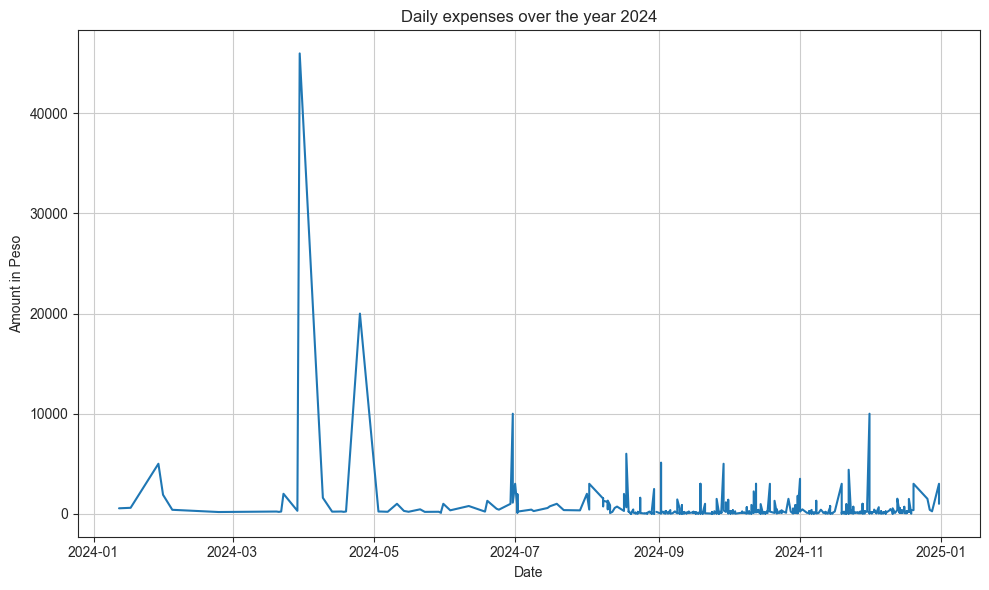

In [28]:
fig = plt.figure(figsize=(10, 6), dpi=100)
plt.plot(df['Date'], df['Amount'], linestyle='-')

plt.title("Daily expenses over the year 2024")
plt.xlabel("Date")
plt.ylabel("Amount in Peso")
plt.tight_layout()  # Ensures labels fit into the figure area
plt.grid(True)

plt.show()


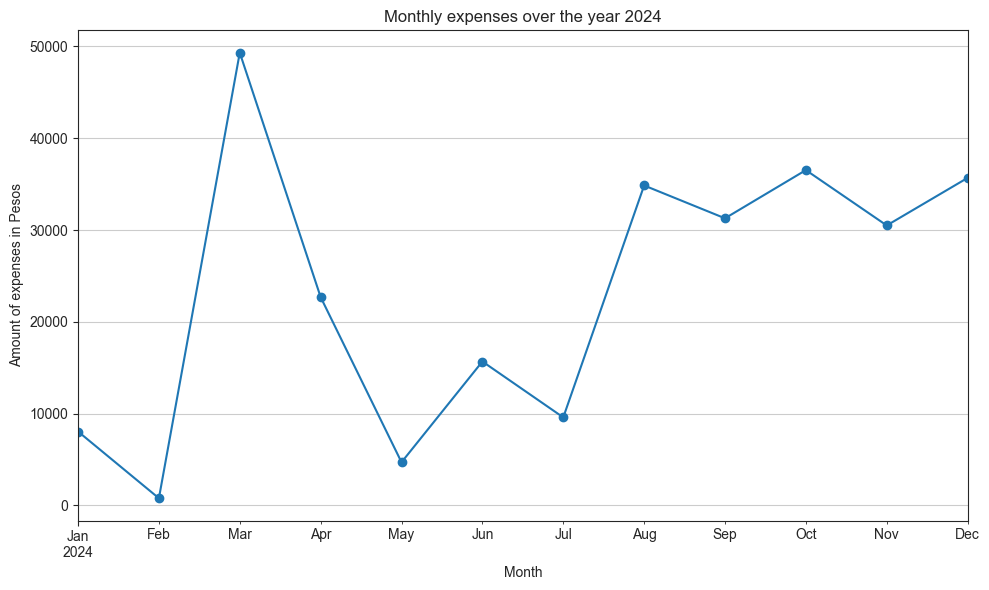

In [ ]:
# plot the monthly expenses over the year
monthly_trends = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()

fig = plt.figure(figsize=(10, 6), dpi=100)
monthly_trends.plot(kind='line', marker='o', title="Monthly expenses over the year 2024")
plt.xlabel("Month")
plt.ylabel("Amount of expenses in Pesos")
plt.tight_layout()
plt.grid(True)
plt.show()